<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/HandlingInconsistentData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

#load data
df = pd.read_csv('/content/03_inconsistent_data.csv')
print('Org data shape : ',df.shape)
print("\nFirst few rows:")
df

Org data shape :  (20, 10)

First few rows:


,Customer_ID,Name,Address,Phone,Email,Birth_Date,Country,State,Annual_Income,Active_Status
0,C001,John Smith,123 Main St,555-0101,john@email.com,1990-01-15,USA,NY,"$50,000",Yes
1,C002,SARAH JOHNSON,456 Oak Ave,(555) 0102,SARAH@EMAIL.COM,02/20/1985,usa,New York,60000,yes
2,C003,mike williams,789 Pine Rd,555.0103,mike@Email.Com,1992-03-10,United States,ny,"$75,000.00",Y
3,C004,Emma Brown,321 Elm St,5550104,emma@email.com,04/05/1988,US,CA,45000,TRUE
4,C005,DAVID JONES,654 Maple Dr,+1-555-0105,DAVID@EMAIL.COM,1995-06-22,U.S.A.,California,"$82,500",True
5,C006,lisa garcia,987 Cedar Ln,555-0106,lisa@Email.Com,07/30/1983,USA,ca,55000,true
6,C007,Robert Miller,147 Birch Way,(555) 0107,robert@email.com,1991-08-14,United States,TX,"$68,000.00",1
7,C008,JENNIFER DAVIS,258 Oak St,555.0108,JENNIFER@EMAIL.COM,09/12/1987,us,Texas,72000,No
8,C009,william rodriguez,369 Pine Ave,5550109,william@Email.Com,1993-10-25,U.S.A.,tx,"$91,000",no
9,C010,Mary Martinez,741 Elm Dr,+1-555-0110,mary@email.com,11/18/1989,USA,FL,63000,N


problems -

In [3]:
#PHONE FORMAT PATTERNS
phone_patterns = df['Phone'].apply(lambda x : re.sub(r'\\d','X',str(x))).value_counts()
phone_patterns

,count
Phone,
555-0101,1
(555) 0102,1
555.0103,1
5550104,1
+1-555-0105,1
555-0106,1
(555) 0107,1
555.0108,1
5550109,1


In [5]:
#Email case patterns
email_patterns = df['Email'].apply(lambda x : "UPPER" if x.isupper() else ("lower" if x.islower() else "mixed") ).value_counts()
email_patterns

,count
Email,
lower,8
UPPER,6
mixed,6


In [21]:
#date format patterns

date_patterns = df['Birth_Date'].apply(lambda x : 'YYYY-MM-DD' if re.match(r'^\\d{4} -\\d{2} - \\d{2}$',str(x)) else'MM\DD\YYYY').value_counts()
date_patterns

,count
Birth_Date,
MM\DD\YYYY,20


In [15]:
#country variations
country_counts = df['Country'].value_counts()
country_counts


,count
Country,
USA,5
United States,4
U.S.A.,4
usa,3
US,2
us,2


In [16]:
#state variations
state_counts = df['State'].value_counts()
state_counts

,count
State,
NY,1
New York,1
ny,1
CA,1
California,1
ca,1
TX,1
Texas,1
tx,1


In [20]:
#Income format patterns
income_patterns = df['Annual_Income'].apply(lambda x : 'with $ and ,' if '$' in str(x) and ',' in str(x) else ('Number only')).value_counts()
income_patterns

,count
Annual_Income,
"with $ and ,",10
Number only,10


In [18]:
#active status
status_counts = df['Active_Status'].value_counts()
status_counts

,count
Active_Status,
Yes,2
No,2
yes,1
Y,1
True,1
TRUE,1
true,1
1,1
no,1


In [22]:
#name case patterns
name_patterns = df['Name'].apply(lambda x : 'UPPER' if x.isupper() else ('lower' if x.islower() else 'Title')).value_counts()
name_patterns

,count
Name,
Title,8
UPPER,6
lower,6


Text(0.5, 1.0, 'Name Case Distribution')

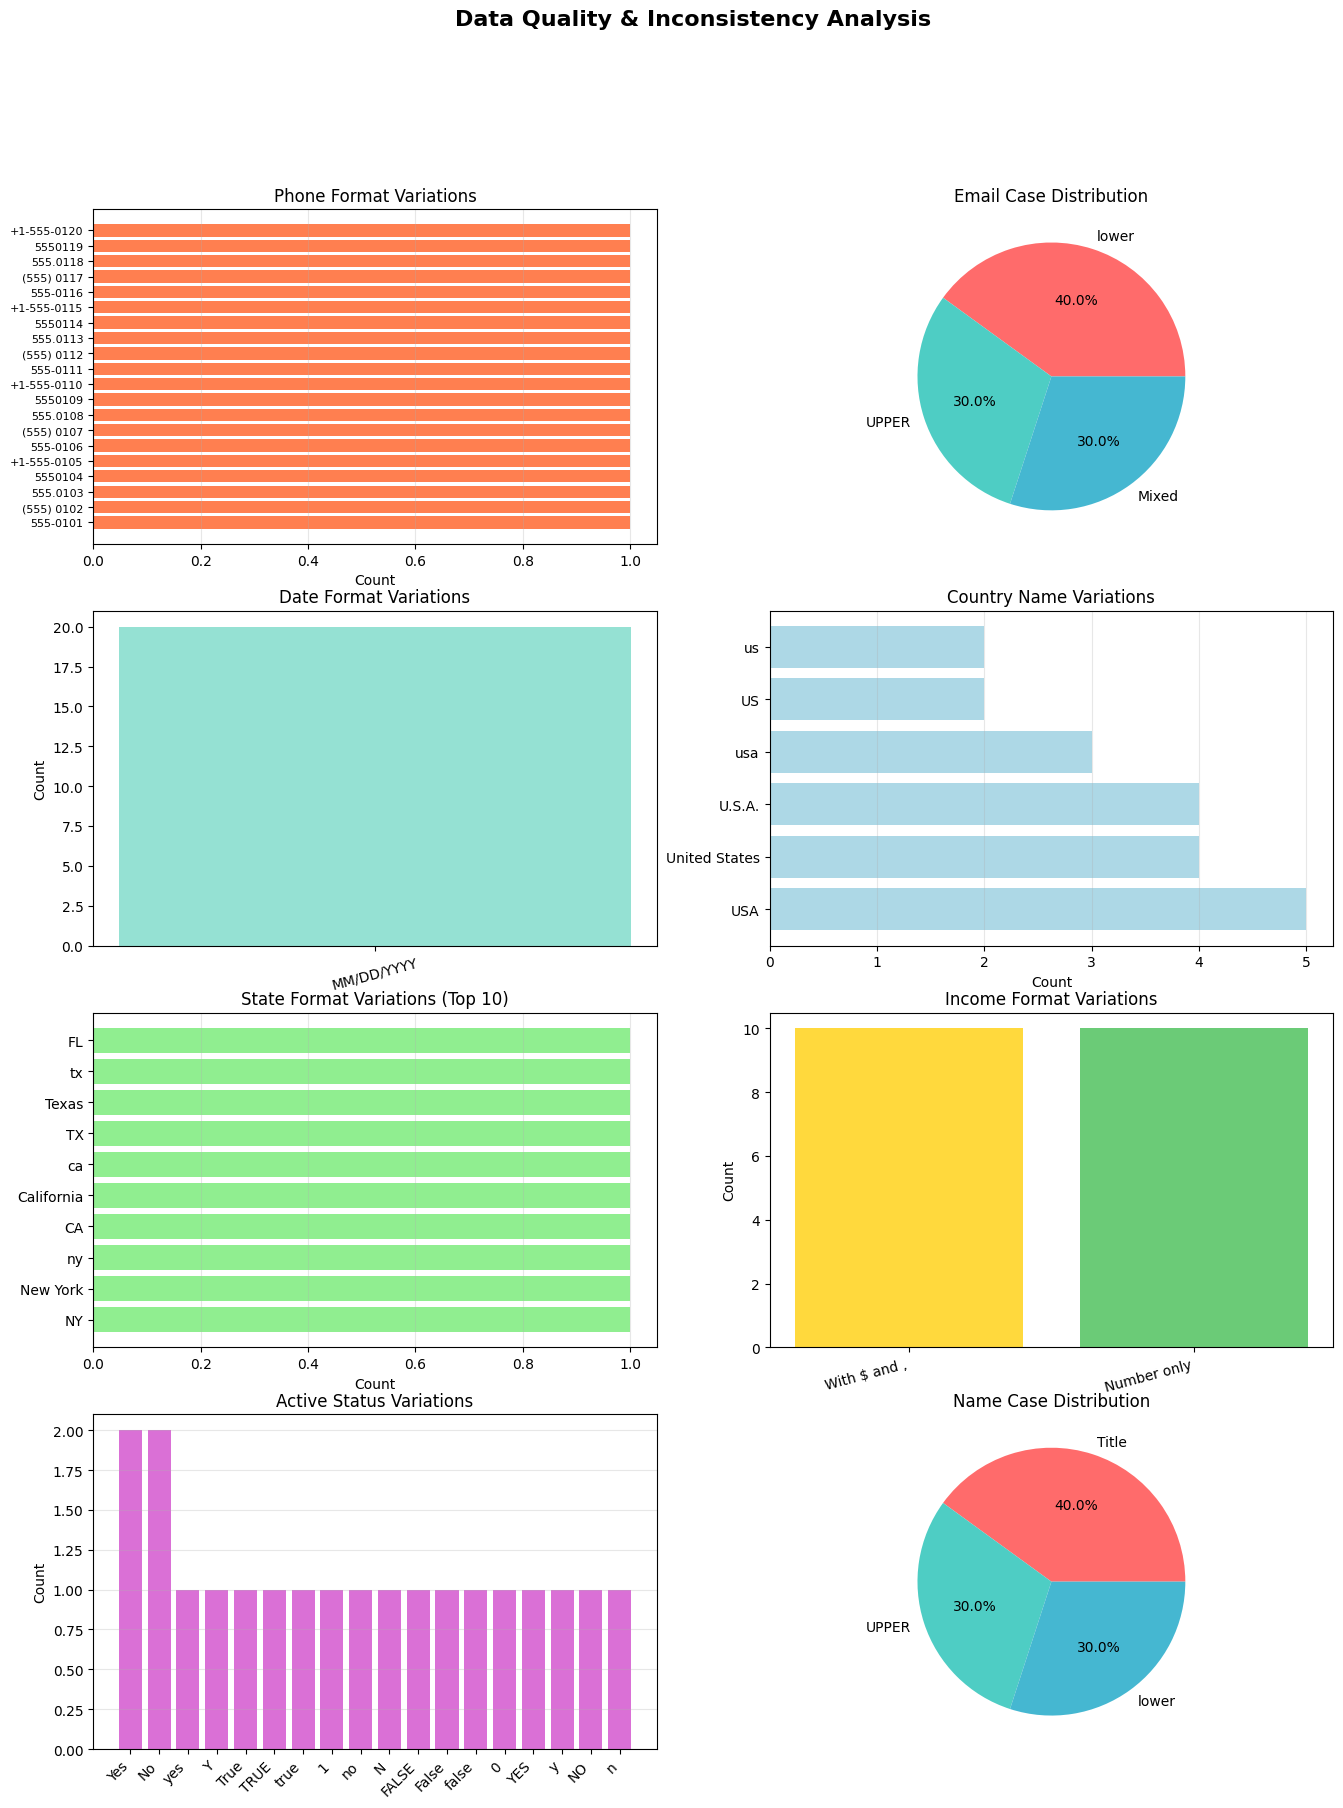

In [40]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Data Quality & Inconsistency Analysis', fontsize=16, fontweight='bold')

# 1. Phone Format Variations
phone_patterns = df['Phone'].apply(lambda x: re.sub(r'\\d', 'X', str(x))).value_counts()
axes[0, 0].barh(range(len(phone_patterns)), phone_patterns.values, color='coral')
axes[0, 0].set_yticks(range(len(phone_patterns)))
axes[0, 0].set_yticklabels(phone_patterns.index, fontsize=8)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Phone Format Variations')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Email Case Variations
email_case = df['Email'].apply(lambda x: 'UPPER' if x.isupper() else ('lower' if x.islower() else 'Mixed')).value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0, 1].pie(email_case.values, labels=email_case.index, autopct='%1.1f%%', colors=colors)
axes[0, 1].set_title('Email Case Distribution')

# 3. Date Format Variations
date_formats = df['Birth_Date'].apply(lambda x:
    'YYYY-MM-DD' if re.match(r'^\\d{4}-\\d{2}-\\d{2}$', str(x)) else 'MM/DD/YYYY').value_counts()
axes[1, 0].bar(date_formats.index, date_formats.values, color=['#95E1D3', '#F38181'])
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Date Format Variations')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Country Variations
country_counts = df['Country'].value_counts()
axes[1, 1].barh(range(len(country_counts)), country_counts.values, color='lightblue')
axes[1, 1].set_yticks(range(len(country_counts)))
axes[1, 1].set_yticklabels(country_counts.index)
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Country Name Variations')
axes[1, 1].grid(axis='x', alpha=0.3)

# 5. State Variations
axes[2, 0].barh(range(len(state_counts)), state_counts.values, color='lightgreen')
axes[2, 0].set_yticks(range(len(state_counts)))
axes[2, 0].set_yticklabels(state_counts.index)
axes[2, 0].set_xlabel('Count')
axes[2, 0].set_title('State Format Variations (Top 10)')
axes[2, 0].grid(axis='x', alpha=0.3)

# 6. Income Format Variations
axes[2, 1].bar(range(len(income_patterns)), income_patterns.values, color=['#FFD93D', '#6BCB77', '#4D96FF'])
axes[2, 1].set_xticks(range(len(income_patterns)))
axes[2, 1].set_xticklabels(income_patterns.index, rotation=15, ha='right')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_title('Income Format Variations')

# 7. Active Status Variations
axes[3, 0].bar(range(len(status_counts)), status_counts.values, color='orchid')
axes[3, 0].set_xticks(range(len(status_counts)))
axes[3, 0].set_xticklabels(status_counts.index, rotation=45, ha='right')
axes[3, 0].set_ylabel('Count')
axes[3, 0].set_title('Active Status Variations')
axes[3, 0].grid(axis='y', alpha=0.3)

# 8. Name Case Variations
axes[3, 1].pie(name_patterns.values, labels=name_patterns.index, autopct='%1.1f%%',
colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[3, 1].set_title('Name Case Distribution')



  **cleaning**

In [43]:
df_clean=df.copy()

#1. Clean Names - Title Case
df_clean['Name'] = df_clean['Name'].str.strip().str.title()

#2. Clean Addresses - Remove extra spaces
df_clean['Address'] = df_clean['Address'].str.strip().str.replace(r'\\s+', ' ', regex=True)

df_clean

,Customer_ID,Name,Address,Phone,Email,Birth_Date,Country,State,Annual_Income,Active_Status
0,C001,John Smith,123 Main St,555-0101,john@email.com,1990-01-15,USA,NY,"$50,000",Yes
1,C002,Sarah Johnson,456 Oak Ave,(555) 0102,SARAH@EMAIL.COM,02/20/1985,usa,New York,60000,yes
2,C003,Mike Williams,789 Pine Rd,555.0103,mike@Email.Com,1992-03-10,United States,ny,"$75,000.00",Y
3,C004,Emma Brown,321 Elm St,5550104,emma@email.com,04/05/1988,US,CA,45000,TRUE
4,C005,David Jones,654 Maple Dr,+1-555-0105,DAVID@EMAIL.COM,1995-06-22,U.S.A.,California,"$82,500",True
5,C006,Lisa Garcia,987 Cedar Ln,555-0106,lisa@Email.Com,07/30/1983,USA,ca,55000,true
6,C007,Robert Miller,147 Birch Way,(555) 0107,robert@email.com,1991-08-14,United States,TX,"$68,000.00",1
7,C008,Jennifer Davis,258 Oak St,555.0108,JENNIFER@EMAIL.COM,09/12/1987,us,Texas,72000,No
8,C009,William Rodriguez,369 Pine Ave,5550109,william@Email.Com,1993-10-25,U.S.A.,tx,"$91,000",no
9,C010,Mary Martinez,741 Elm Dr,+1-555-0110,mary@email.com,11/18/1989,USA,FL,63000,N


In [47]:
#3. Clean phone numbers - standardize to xxx-xxxxformat

def clean_phone(phone):
    #Remove all non-digit characters
    digits = re.sub(r'\\D','',str(phone))
    #Take last 7 digits
    digits = digits[-7:]
    #format as xx-xxxx
    return f'{digits[:3]}-{digits[3:]}'

df_clean['Phone'] = df_clean['Phone'].apply(clean_phone)
df_clean


,Customer_ID,Name,Address,Phone,Email,Birth_Date,Country,State,Annual_Income,Active_Status
0,C001,John Smith,123 Main St,55--0101,john@email.com,1990-01-15,USA,NY,"$50,000",Yes
1,C002,Sarah Johnson,456 Oak Ave,5) -0102,SARAH@EMAIL.COM,02/20/1985,usa,New York,60000,yes
2,C003,Mike Williams,789 Pine Rd,55.-0103,mike@Email.Com,1992-03-10,United States,ny,"$75,000.00",Y
3,C004,Emma Brown,321 Elm St,555-0104,emma@email.com,04/05/1988,US,CA,45000,TRUE
4,C005,David Jones,654 Maple Dr,55--0105,DAVID@EMAIL.COM,1995-06-22,U.S.A.,California,"$82,500",True
5,C006,Lisa Garcia,987 Cedar Ln,55--0106,lisa@Email.Com,07/30/1983,USA,ca,55000,true
6,C007,Robert Miller,147 Birch Way,5) -0107,robert@email.com,1991-08-14,United States,TX,"$68,000.00",1
7,C008,Jennifer Davis,258 Oak St,55.-0108,JENNIFER@EMAIL.COM,09/12/1987,us,Texas,72000,No
8,C009,William Rodriguez,369 Pine Ave,555-0109,william@Email.Com,1993-10-25,U.S.A.,tx,"$91,000",no
9,C010,Mary Martinez,741 Elm Dr,55--0110,mary@email.com,11/18/1989,USA,FL,63000,N


In [48]:
#4. CLEAN EMAIL - LOWERCASE
df_clean['Email'] = df_clean['Email'].str.lower().str.strip()
df_clean

,Customer_ID,Name,Address,Phone,Email,Birth_Date,Country,State,Annual_Income,Active_Status
0,C001,John Smith,123 Main St,55--0101,john@email.com,1990-01-15,USA,NY,"$50,000",Yes
1,C002,Sarah Johnson,456 Oak Ave,5) -0102,sarah@email.com,02/20/1985,usa,New York,60000,yes
2,C003,Mike Williams,789 Pine Rd,55.-0103,mike@email.com,1992-03-10,United States,ny,"$75,000.00",Y
3,C004,Emma Brown,321 Elm St,555-0104,emma@email.com,04/05/1988,US,CA,45000,TRUE
4,C005,David Jones,654 Maple Dr,55--0105,david@email.com,1995-06-22,U.S.A.,California,"$82,500",True
5,C006,Lisa Garcia,987 Cedar Ln,55--0106,lisa@email.com,07/30/1983,USA,ca,55000,true
6,C007,Robert Miller,147 Birch Way,5) -0107,robert@email.com,1991-08-14,United States,TX,"$68,000.00",1
7,C008,Jennifer Davis,258 Oak St,55.-0108,jennifer@email.com,09/12/1987,us,Texas,72000,No
8,C009,William Rodriguez,369 Pine Ave,555-0109,william@email.com,1993-10-25,U.S.A.,tx,"$91,000",no
9,C010,Mary Martinez,741 Elm Dr,55--0110,mary@email.com,11/18/1989,USA,FL,63000,N


In [49]:
def clean_data_manual(df):
    """Manual cleaning approach with custom functions"""

    df_clean = df.copy()

    # 1. Clean Names - Title Case
    df_clean['Name'] = df_clean['Name'].str.strip().str.title()

    # 2. Clean Addresses - Remove extra spaces
    df_clean['Address'] = df_clean['Address'].str.strip().str.replace(r'\\s+', ' ', regex=True)

    # 3. Clean Phone Numbers - Standardize to XXX-XXXX format
    def clean_phone(phone):
        # Remove all non-digit characters
        digits = re.sub(r'\\D', '', str(phone))
        # Take last 7 digits
        digits = digits[-7:]
        # Format as XXX-XXXX
        return f"{digits[:3]}-{digits[3:]}"

    df_clean['Phone'] = df_clean['Phone'].apply(clean_phone)

    # 4. Clean Email - Lowercase
    df_clean['Email'] = df_clean['Email'].str.lower().str.strip()

    # 5. Clean Birth Date - Standardize to YYYY-MM-DD
    def clean_date(date_str):
        try:
            # Try MM/DD/YYYY format
            if '/' in str(date_str):
                return pd.to_datetime(date_str, format='%m/%d/%Y').strftime('%Y-%m-%d')
            # Try YYYY-MM-DD format
            else:
                return pd.to_datetime(date_str, format='%Y-%m-%d').strftime('%Y-%m-%d')
        except:
            return date_str

    df_clean['Birth_Date'] = df_clean['Birth_Date'].apply(clean_date)

    # 6. Clean Country - Standardize to USA
    df_clean['Country'] = 'USA'

    # 7. Clean State - Standardize to 2-letter codes
    state_mapping = {
        'ny': 'NY', 'new york': 'NY',
        'ca': 'CA', 'california': 'CA',
        'tx': 'TX', 'texas': 'TX',
        'fl': 'FL', 'florida': 'FL',
        'il': 'IL', 'illinois': 'IL',
        'pa': 'PA', 'pennsylvania': 'PA',
        'oh': 'OH', 'ohio': 'OH'
    }
    df_clean['State'] = df_clean['State'].str.lower().str.strip().map(state_mapping).fillna(df_clean['State'].str.upper())

    # 8. Clean Annual Income - Convert to integer
    def clean_income(income):
        # Remove $, commas, and convert to float then int
        income_str = str(income).replace('$', '').replace(',', '')
        return int(float(income_str))

    df_clean['Annual_Income'] = df_clean['Annual_Income'].apply(clean_income)

    # 9. Clean Active Status - Convert to boolean
    true_values = ['yes', 'y', 'true', '1', 'TRUE', 'True', 'YES', 'Y']
    df_clean['Active_Status'] = df_clean['Active_Status'].astype(str).str.strip().isin(true_values)

    return df_clean

# Apply manual cleaning
df_cleaned_manual = clean_data_manual(df)
print("\\n" + "="*50)
print("MANUAL CLEANING RESULTS")
print("="*50)
print(df_cleaned_manual.head(10))

\n==================================================
MANUAL CLEANING RESULTS
  Customer_ID               Name        Address     Phone               Email  \
0        C001         John Smith    123 Main St  55--0101      john@email.com   
1        C002      Sarah Johnson    456 Oak Ave  5) -0102     sarah@email.com   
2        C003      Mike Williams    789 Pine Rd  55.-0103      mike@email.com   
3        C004         Emma Brown     321 Elm St  555-0104      emma@email.com   
4        C005        David Jones   654 Maple Dr  55--0105     david@email.com   
5        C006        Lisa Garcia   987 Cedar Ln  55--0106      lisa@email.com   
6        C007      Robert Miller  147 Birch Way  5) -0107    robert@email.com   
7        C008     Jennifer Davis   258  Oak  St  55.-0108  jennifer@email.com   
8        C009  William Rodriguez   369 Pine Ave  555-0109   william@email.com   
9        C010      Mary Martinez     741 Elm Dr  55--0110      mary@email.com   

   Birth_Date Country State  An

In [50]:
def clean_data_regex(df):
    """Cleaning using regex and advanced pandas operations"""

    df_clean = df.copy()

    # Clean with regex patterns
    df_clean['Name'] = (df_clean['Name']
                        .str.strip()
                        .str.replace(r'\s+', ' ', regex=True)
                        .str.title())

    df_clean['Address'] = (df_clean['Address']
                          .str.strip()
                          .str.replace(r'\s+', ' ', regex=True))

    # Phone: Extract digits and reformat
    df_clean['Phone'] = (df_clean['Phone']
                        .astype(str)
                        .str.replace(r'\D', '', regex=True)
                        .str[-7:]
                        .str.replace(r'(\d{3})(\d{4})', r'\1-\2', regex=True))

    # Email: Lowercase
    df_clean['Email'] = df_clean['Email'].str.lower().str.strip()

    # Date: Use pd.to_datetime with format='mixed' for mixed formats
    df_clean['Birth_Date'] = pd.to_datetime(df_clean['Birth_Date'],
                                            format='mixed',
                                            dayfirst=False).dt.strftime('%Y-%m-%d')

    # Country: Replace with standard
    df_clean['Country'] = df_clean['Country'].replace({
        'usa': 'USA', 'us': 'USA', 'U.S.A.': 'USA', 'United States': 'USA'
    })

    # State: Uppercase and map
    state_dict = {
        'NEW YORK': 'NY', 'CALIFORNIA': 'CA', 'TEXAS': 'TX',
        'FLORIDA': 'FL', 'ILLINOIS': 'IL', 'PENNSYLVANIA': 'PA', 'OHIO': 'OH'
    }
    df_clean['State'] = (df_clean['State']
                        .str.upper()
                        .str.strip()
                        .replace(state_dict))

    # Income: Remove non-numeric and convert
    df_clean['Annual_Income'] = (df_clean['Annual_Income']
                                .astype(str)
                                .str.replace(r'[$,]', '', regex=True)
                                .astype(float)
                                .astype(int))

    # Active Status: Map to boolean
    status_map = {
        'Yes': True, 'YES': True, 'yes': True, 'Y': True, 'y': True,
        'True': True, 'TRUE': True, 'true': True, '1': True,
        'No': False, 'NO': False, 'no': False, 'N': False, 'n': False,
        'False': False, 'FALSE': False, 'false': False, '0': False
    }
    df_clean['Active_Status'] = df_clean['Active_Status'].astype(str).map(status_map)

    return df_clean

# Apply regex cleaning
df_cleaned_regex = clean_data_regex(df)
print("\n" + "="*50)
print("REGEX CLEANING RESULTS")
print("="*50)
print(df_cleaned_regex.head(10))
print("\n" + "="*50)
print("Data Types:")
print("="*50)
print(df_cleaned_regex.dtypes)


REGEX CLEANING RESULTS
  Customer_ID               Name        Address     Phone               Email  \
0        C001         John Smith    123 Main St  555-0101      john@email.com   
1        C002      Sarah Johnson    456 Oak Ave  555-0102     sarah@email.com   
2        C003      Mike Williams    789 Pine Rd  555-0103      mike@email.com   
3        C004         Emma Brown     321 Elm St  555-0104      emma@email.com   
4        C005        David Jones   654 Maple Dr  555-0105     david@email.com   
5        C006        Lisa Garcia   987 Cedar Ln  555-0106      lisa@email.com   
6        C007      Robert Miller  147 Birch Way  555-0107    robert@email.com   
7        C008     Jennifer Davis     258 Oak St  555-0108  jennifer@email.com   
8        C009  William Rodriguez   369 Pine Ave  555-0109   william@email.com   
9        C010      Mary Martinez     741 Elm Dr  555-0110      mary@email.com   

   Birth_Date Country State  Annual_Income  Active_Status  
0  1990-01-15     USA   